In [70]:
import pandas as pd 
import numpy as np
import random
import os 
import argparse
import json
import torch
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from attrdict import AttrDict
from transformers import BertConfig, BertTokenizer, BertModel
from transformers import DistilBertModel, DistilBertTokenizer, DistilBertConfig, DistilBertForSequenceClassification
from transformers import RobertaModel, RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from transformers import AdamW, get_linear_schedule_with_warmup

In [71]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
model_path = os.path.join(default_path, '../models')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
config_file = "bert-base.json"

In [72]:
criteria = 4

In [73]:
X_train = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_test.csv'))

In [74]:
X_test.head(3)

,text,text_kor,label
0,So I need to sleep if any1 leaves any comment...,그래서 나는 만약 누군가가 이번에 댓글을 남기면 잠을 자야 한다. 고마워 그리고 나...,1
1,I woke up pretty early and could not sleep so...,나는 꽤 일찍 일어나서 잠을 잘 수가 없어서 일어나서 대신 선형대수학 공부를 했다,0
2,Im on 300mg twice of lithium 75mg effexor twi...,나는 300mg의 리튬 75mg의 에펙스를 두 번 또는 하루에 두 번 복용하고 필요...,7


In [75]:
reddit = pd.read_csv(os.path.join(data_path, 'reddit_dsm_ngram.csv'))
reddit.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False


In [76]:
untagged_data = reddit[reddit.label==2]
print(f'len data: {len(untagged_data)}')
untagged_data.head(1)

len data: 7666


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
107425,t3_cg8atp,depression,MavYaBoy,Ive gained weight because of my stress eating ...,comment,1.563768e+09,t3_cg8atp,eufbl8s,24,2,True,False,False


In [77]:
untagged_data.reset_index(inplace=True, drop=True)

In [78]:
untagged_data[untagged_data.text==' ']

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c


In [79]:
model_name = 'distilbert-base-uncased'

In [80]:
tokenizer = DistilBertTokenizer.from_pretrained(model_name, model_max_length=128)
config = DistilBertConfig.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)
model = DistilBertModel.from_pretrained(model_name, config=config)

In [81]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [82]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [83]:
training_config.model_path = model_path 
training_config.log_path = log_path

In [84]:
training_config

AttrDict({'default_path': '../', 'data_path': 'data', 'log_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../log', 'model_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../models', 'config_path': 'config', 'seed': 42, 'train_batch_size': 8, 'device': device(type='cuda'), 'eval_batch_size': 8, 'num_epochs': 5, 'gradient_accumulation_steps': 1, 'warmup_proportion': 0, 'adam_epsilon': 1e-08, 'learning_rate': 5e-05, 'do_lower_case': False, 'no_cuda': False, 'max_steps': -1, 'logging_steps': 100})

In [85]:
training_config.learning_rate

5e-05

In [86]:
training_config.pad = 'max_length'
training_config.num_epochs = 10

In [87]:
class DSMDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file
    
    def __len__(self):
        return len(self.data.label)
    
    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)
    
    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [88]:
class DSMProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer 
        self.max_len = config.max_position_embeddings
        self.pad = training_config.pad
        self.batch_size = training_config.train_batch_size
        self.truncation = truncation
    
    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text, 
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )
        
        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1] 
            except:
                inputs['label'] = 0 
            features.append(inputs)
        
        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        # all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        # dataset = TensorDataset(all_input_ids, all_attention_mask, all_token_type_ids, all_labels)
        dataset = TensorDataset(all_input_ids, all_attention_mask, all_labels)
        return dataset
    
    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)
        
    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [89]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [90]:
class BWSRegressor(nn.Module):
    def __init__(self, config, model):
        super(BWSRegressor, self).__init__()
        self.model = model
        self.linear = nn.Linear(config.hidden_size, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 1)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.last_hidden_state[:, 0, :]
        # print(f'logits: {len(logits)}, {len(logits[0])}')
        x = self.linear(logits)
        x = self.relu(x)
        score = self.out(x)
        # print(f'score: {score}')
        return score 

In [91]:
class BWSTrainer():
    def __init__(self, config, training_config, model, model_name, train_dataloader, eval_dataloader):
        self.config = config
        self.training_config = training_config
        self.model = model
        self.model_name = model_name
        self.train_dataloader = train_dataloader
        self.eval_dataloader = eval_dataloader
        
    def set_seed(self):
        random.seed(self.training_config.seed)
        np.random.seed(self.training_config.seed)
        torch.manual_seed(self.training_config.seed)
        if not self.training_config.no_cuda and torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.training_config.seed)
    
    def train(self):
        global_step = 0; nb_eval_steps = 0
        train_rmse = []; eval_rmse = []
        t_total = len(self.train_dataloader) // self.training_config.gradient_accumulation_steps * self.training_config.num_epochs

        optimizer = AdamW(self.model.parameters(), lr=self.training_config.learning_rate, eps=self.training_config.adam_epsilon)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(t_total * self.training_config.warmup_proportion), \
                                                    num_training_steps=t_total)
        
        criterion = RMSELoss
        # criterion = nn.MSELoss()
        best_loss = 9999 
        
        self.model.zero_grad()
        for epoch in range(int(self.training_config.num_epochs)):
            train_loss = 0.0; eval_loss = 0.0 
            
            for step, batch in enumerate(self.train_dataloader):
                self.model.train()
                batch = tuple(t.to(self.training_config.device) for t in batch)
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    # "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(f'output: {type(outputs)}, {outputs.squeeze}')
                label = batch[2]
                # print(f'label: {label}')
                # print(f'output: {outputs}, {outputs.squeeze()}')
                loss = criterion(outputs.squeeze(), batch[2].type_as(outputs))
                loss.backward()
                
                train_loss += loss.item()
                # torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.training_config.max_grad_norm)
                optimizer.step()
                scheduler.step()
                
                self.model.zero_grad()
            
            print(f'epoch: {epoch + 1} done, train_loss: {train_loss / len(self.train_dataloader)}')
            train_rmse.append(train_loss / len(self.train_dataloader))

            for step2, batch2 in enumerate(self.eval_dataloader):
                self.model.eval()
                batch2 = tuple(t.to(self.training_config.device) for t in batch2)

                with torch.no_grad():
                    inputs = {
                        "input_ids": batch2[0],
                        "attention_mask": batch2[1],
                        # "token_type_ids": batch2[2],
                    }
                    label2 = batch2[2]
                    outputs = self.model(**inputs)
                    tmp_eval_loss = criterion(outputs.squeeze(), label2.type_as(outputs))
                    eval_loss += tmp_eval_loss.mean().item()
                    
                nb_eval_steps += 1

            eval_loss = eval_loss / nb_eval_steps
            eval_rmse.append(eval_loss)
        return train_rmse, eval_rmse
            
    def save_log(self, train_mse, eval_mse, epoch):
        with open(os.path.join(self.training_config.log_path, f'train_{epoch}_bmse.pickle'), 'wb') as f:
            pickle.dump(train_mse, f, pickle.HIGHEST_PROTOCOL)  
        
        with open(os.path.join(self.training_config.log_path, f'eval_{epoch}_bmse.pickle'), 'wb') as f:
            pickle.dump(eval_mse, f, pickle.HIGHEST_PROTOCOL)  
    
    def save_model(self, model_name):
        torch.save(self.model.state_dict(), model_name)

In [92]:
train_file = DSMDataset(X_train)
val_file = DSMDataset(X_dev)
test_file = DSMDataset(X_test)

In [93]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [94]:
dsm_processor = DSMProcessor(config, training_config, tokenizer)

In [95]:
train_dataset = dsm_processor.convert_data(train_file)
val_dataset = dsm_processor.convert_data(val_file)
test_dataset = dsm_processor.convert_data(test_file)

In [96]:
train_sampler = dsm_processor.shuffle_data(train_dataset, 'train')
val_sampler = dsm_processor.shuffle_data(val_dataset, 'eval')
test_sampler = dsm_processor.shuffle_data(test_dataset, 'test')

In [97]:
train_dataloader = dsm_processor.load_data(train_dataset, train_sampler)
val_dataloader = dsm_processor.load_data(val_dataset, val_sampler)
test_dataloader = dsm_processor.load_data(test_dataset, test_sampler)

In [98]:
len(train_dataloader), len(val_dataloader)

(144, 16)

In [99]:
model_reg = BWSRegressor(config, model).to(training_config.device)  

In [100]:
bws_trainer = BWSTrainer(config, training_config, model_reg, model_name, train_dataloader, val_dataloader)

In [101]:
train_mse, eval_mse = bws_trainer.train()

C:\Users\lamda\.conda\envs\aaai\lib\site-packages\transformers\optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


epoch: 1 done, train_loss: 2.624290407531791
epoch: 2 done, train_loss: 2.005860038101673
epoch: 3 done, train_loss: 1.5833469322986073
epoch: 4 done, train_loss: 1.2007417318721612
epoch: 5 done, train_loss: 1.005618004128337
epoch: 6 done, train_loss: 0.8130020899698138
epoch: 7 done, train_loss: 0.6962380049129328
epoch: 8 done, train_loss: 0.5691215005806751
epoch: 9 done, train_loss: 0.48076276087926495
epoch: 10 done, train_loss: 0.41054091442169416


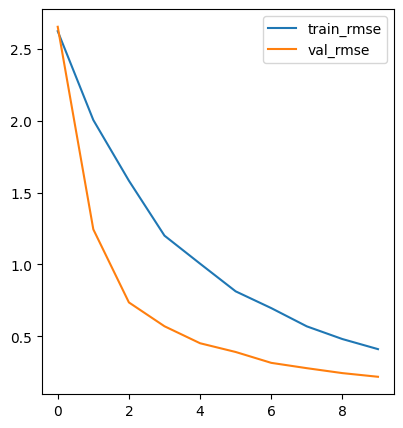

In [102]:
num_epochs = list(range(len(train_mse)))
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(list(range(len(train_mse))), train_mse, label='train_rmse')
plt.plot(list(range(len(eval_mse))), eval_mse, label='val_rmse')

plt.legend()
plt.show()

In [103]:
save_model = f'distil_a{criteria}_e10.pt'

In [104]:
bws_trainer.save_model(os.path.join(model_path, save_model))

In [ ]:
class BertRegTester():
    def __init__(self, training_config, model):
        self.training_config = training_config
        self.model = model

    def get_label(self, test_dataloader, test_type):
        '''
        test_type: 0  -> Test dataset 
        test_type: 1  -> Test sentence
        '''
        preds = []
        labels = []

        for batch in test_dataloader:
            self.model.eval()   # self 안 붙이면 이상한 Output (BaseModelOutputWithPoolingAndCrossAttentions) 출력 
            batch = tuple(t.to(self.training_config.device) for t in batch)   # args.device: cuda 
            with torch.no_grad():
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(outputs, outputs.squeeze().detach().cpu().numpy())
                # print(len(preds))
                if test_type == 0:
                    try:
                        preds.extend(list(outputs.squeeze().detach().cpu().numpy()))
                    except:
                        preds.append(outputs.squeeze().detach().cpu().numpy())
                elif test_type == 1:
                    preds.extend(outputs[0].detach().cpu().numpy())            
            label = batch[3].detach().cpu().numpy()
            labels.extend(label)
        return preds, labels 

In [ ]:
bert_tester = BertRegTester(training_config, model_reg)

In [ ]:
import time 

start = time.time()
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)
print(f'소요 시간: {time.time() - start}')

In [ ]:
y_pred[:3] ,y_true[:3]

In [ ]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [ ]:
criterion = RMSELoss

In [ ]:
loss = criterion(torch.Tensor(y_pred), torch.Tensor((y_true)))
loss

In [ ]:
r2score = R2Score()
r2score(torch.Tensor(y_pred), torch.Tensor(y_true))

In [ ]:
conv = ['hey', 'I feel very depressed', 'I feed depressed', 'I feel sad', 'I cry everyday', 'I went to school', 'I want to die']
dep_test = pd.DataFrame(conv, columns=['text'])
dep_test['label'] = 9999

In [ ]:
test_file = BertDataset(dep_test)
test_dataset = bert_processor.convert_data(test_file)
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [ ]:
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)

In [ ]:
dep_test['label'] = [pred for pred in y_pred]
dep_test

In [ ]:
untagged_file = BertDataset(untagged_data)
untagged_dataset = bert_processor.convert_data(untagged_file)
untagged_sampler = bert_processor.shuffle_data(untagged_dataset, 'test')
untagged_dataloader = bert_processor.load_data(untagged_dataset, untagged_sampler)

In [ ]:
untagged_file

In [ ]:
len(untagged_data)

In [ ]:
y_pred, y_true = bert_tester.get_label(untagged_dataloader, 0)

In [ ]:
len(y_pred), len(y_true)

In [ ]:
y_pred[-1]

In [ ]:
def convert_score(score):
    if score < 0:
        score = 0
    elif score >= 11:
        score = 10
    return int(score)

In [ ]:
untagged_data['pseudo'] = y_pred
untagged_data['pseudo'] = untagged_data.pseudo.apply(convert_score)
untagged_data

In [ ]:
untagged_data.groupby('pseudo').count()

In [ ]:
untagged_data.to_csv(os.path.join(data_path, 'untagged_a3_pseudo.csv'), index=False)

In [ ]:
a1_train, a1_test = train_test_split(untagged_data, test_size=0.2, random_state=42) #, stratify=a1.label)
a1_train, a1_dev = train_test_split(a1_train, test_size=0.1, random_state=42) #, stratify=a1_train.label)

In [ ]:
a1_train.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_train.csv'), index=False)
a1_dev.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_val.csv'), index=False)
a1_test.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_test.csv'), index=False)